Type of image: <class 'PIL.PngImagePlugin.PngImageFile'>
Image format: PNG
Image mode: RGB
Image size: (1024, 1024)


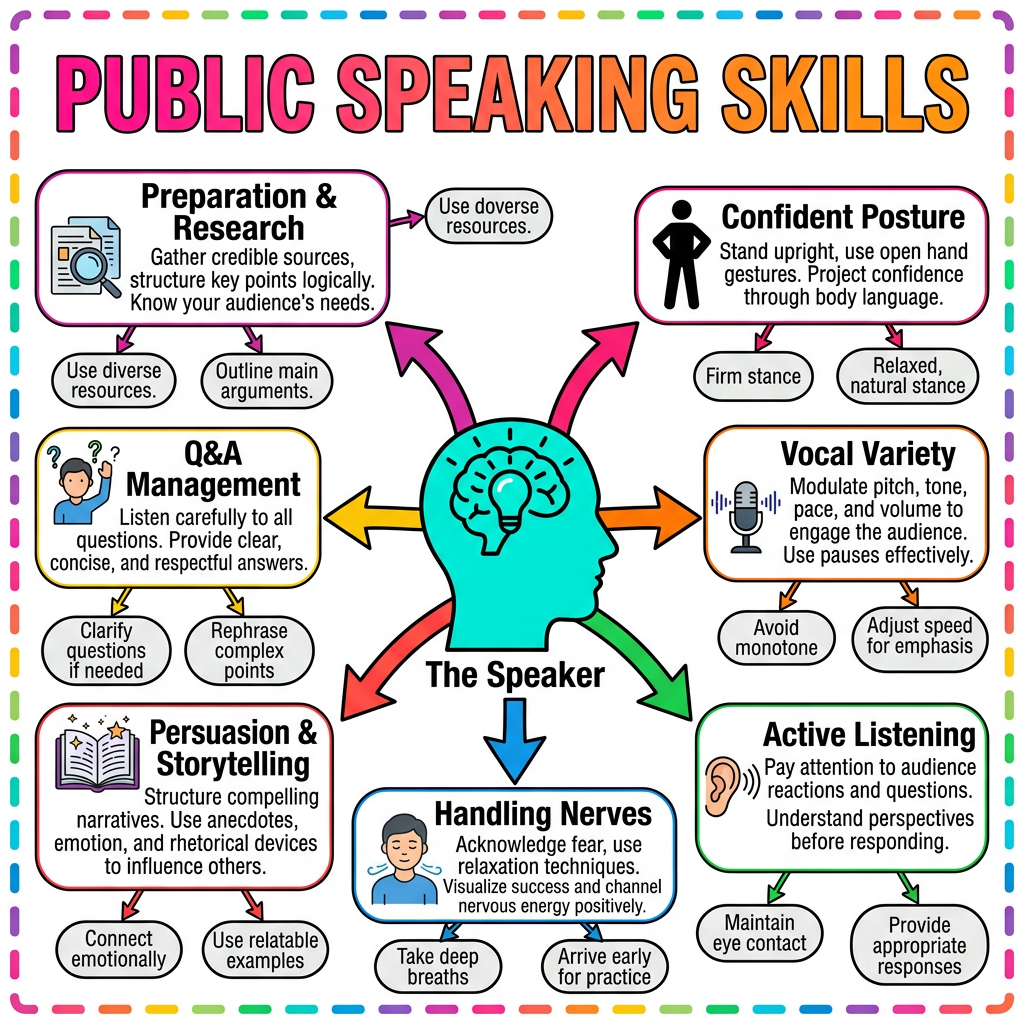

Resized image size: (500, 500)


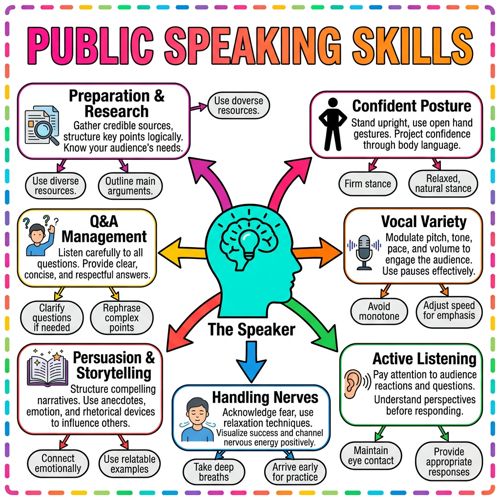

In [2]:
from PIL import Image
from IPython.display import display

# Load the image
img = Image.open("/Users/dulika/Downloads/Brain Map.png")

# 1. Check the type
print("Type of image:", type(img))

# 2. Print image information
print("Image format:", img.format)
print("Image mode:", img.mode)
print("Image size:", img.size)

# 3. Display/print the original image
display(img)

# 4. Resize the image
resized_img = img.resize((500, 500))

# 5. Print the resized image size
print("Resized image size:", resized_img.size)

# 6. Display the resized image
display(resized_img)

In [3]:
from PIL import Image

img = Image.open("/Users/dulika/Downloads/Brain Map.png")

# Resize
resized_img = img.resize((500, 500))

# Save
resized_img.save("resized_brain_map.png")

print("Image resized and saved successfully!")

Image resized and saved successfully!


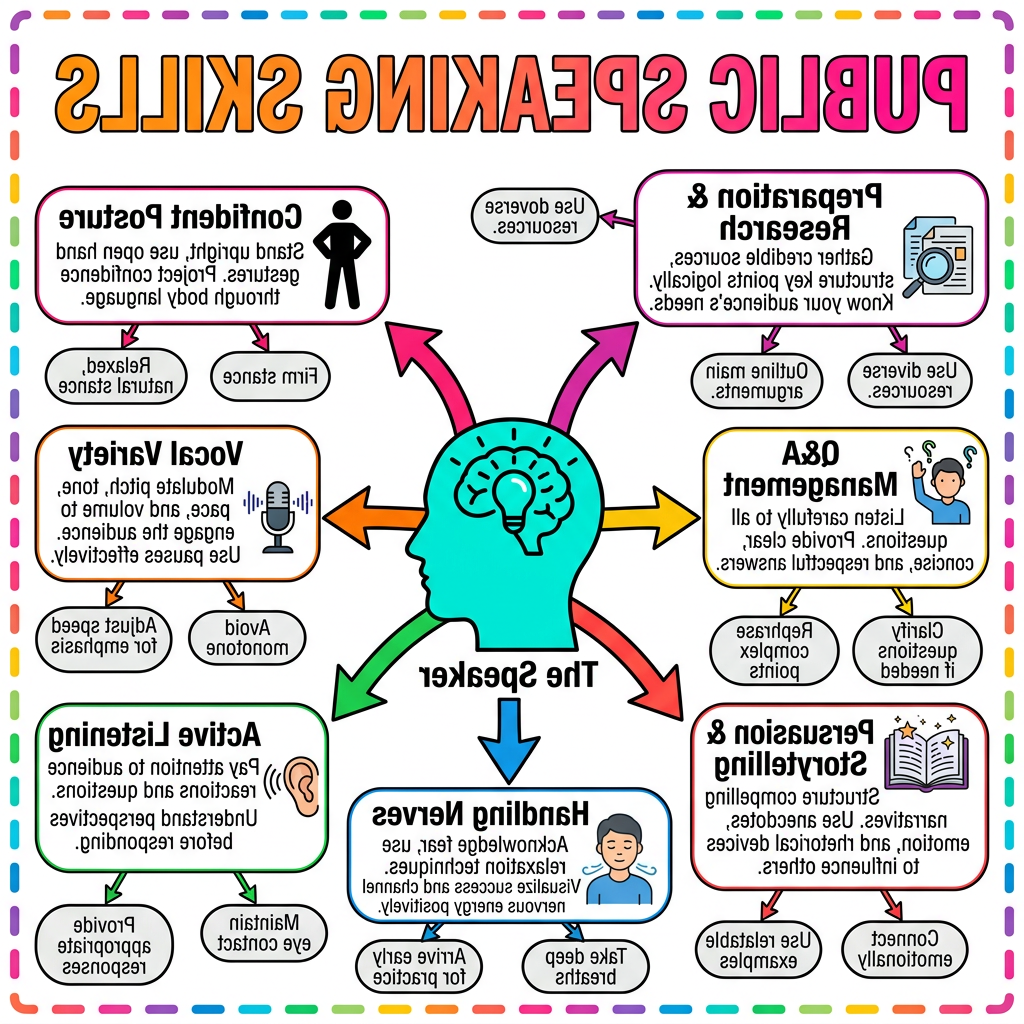

Flipped image size: (1024, 1024)


In [4]:
# Flip horizontally
flipped_img = img.transpose(Image.FLIP_LEFT_RIGHT)

# Display flipped image
display(flipped_img)

# Print size
print("Flipped image size:", flipped_img.size)

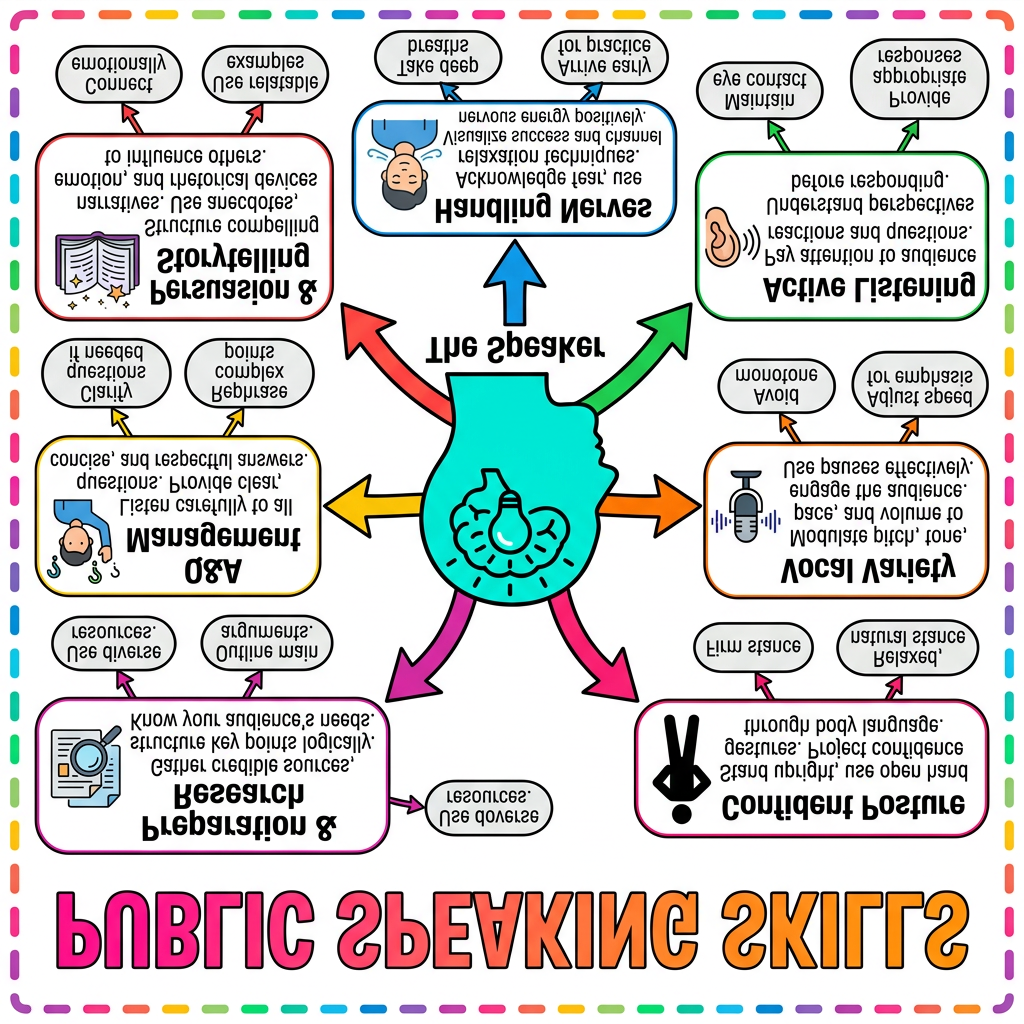

In [5]:
# Flip vertically
flipped_img = img.transpose(Image.FLIP_TOP_BOTTOM)

display(flipped_img)

Original image size: (1024, 1024)


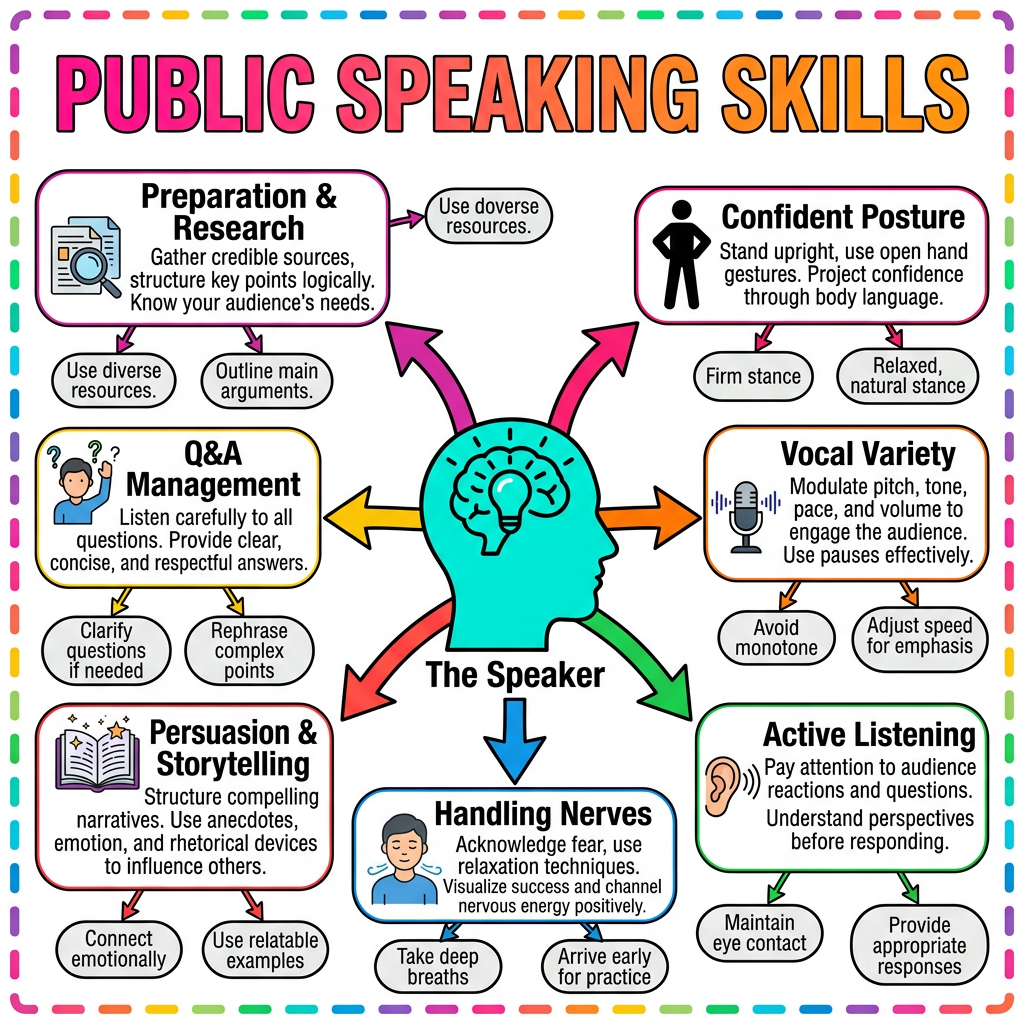

Cropped image size: (400, 400)


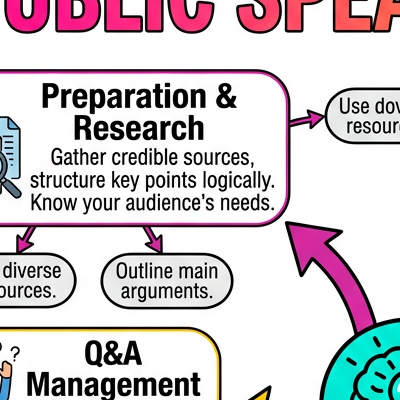

In [9]:
from PIL import Image
from IPython.display import display

# Load the image
img = Image.open("/Users/dulika/Downloads/Brain Map.png")

# Print original image information
print("Original image size:", img.size)

# Display original image
display(img)

# Crop the image
# Coordinates: (left, upper, right, lower)
cropped_img = img.crop((100, 100, 500, 500))

# Print cropped image size
print("Cropped image size:", cropped_img.size)

# Display cropped image
display(cropped_img)

In [14]:
%pip install ultralytics opencv-python

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import cv2
from ultralytics import YOLO

# Load YOLOv8 Nano model
model = YOLO("yolov8n.pt")

# Open the default webcam
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open webcam.")
else:
    print("Starting Object Counter...")
    print("Press 'q' to quit.")

    while True:
        # Read a frame from the webcam
        success, frame = cap.read()

        if not success:
            print("Error: Could not read camera frame.")
            break

        # Detect objects
        results = model(frame, verbose=False)

        # Count detected objects
        detected_count = len(results[0].boxes)

        # Draw bounding boxes and labels
        annotated_frame = results[0].plot()

        # Display total object count
        cv2.putText(
            annotated_frame,
            f"Total Objects: {detected_count}",
            (20, 50),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 255, 0),
            2
        )

        # Show the video
        cv2.imshow(
            "Real-Time Object Counter",
            annotated_frame
        )

        # Press q to exit
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    # Release resources
    cap.release()
    cv2.destroyAllWindows()

    print("Camera feed closed successfully.")

Starting Object Counter...
Press 'q' to quit.


In [ ]:
q

In [1]:
%pip install opencv-python numpy

Note: you may need to restart the kernel to use updated packages.


In [1]:
import cv2
import numpy as np

# Open webcam
cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)

if not cap.isOpened():
    print("Error: Could not open webcam.")
else:
    # Blue color range in HSV
    LOWER_BLUE = np.array([100, 150, 50])
    UPPER_BLUE = np.array([140, 255, 255])

    # Create drawing canvas
    canvas = None

    # Store previous point
    prev_point = None

    print("Air Canvas Started!")
    print("Wave a BLUE object in front of the camera to draw.")
    print("Press 'c' to clear the canvas.")
    print("Press 'q' to quit.")

    while True:

        # Read camera frame
        success, frame = cap.read()

        if not success:
            print("Error: Could not read camera frame.")
            break

        # Flip camera horizontally
        frame = cv2.flip(frame, 1)

        # Create black canvas
        if canvas is None:
            canvas = np.zeros_like(frame)

        # Convert BGR image to HSV
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

        # Create mask for blue color
        mask = cv2.inRange(
            hsv,
            LOWER_BLUE,
            UPPER_BLUE
        )

        # Remove small noise
        mask = cv2.erode(mask, None, iterations=1)
        mask = cv2.dilate(mask, None, iterations=2)

        # Find contours
        contours, _ = cv2.findContours(
            mask,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        current_point = None

        # Check if blue object is detected
        if contours:

            # Find largest contour
            largest_contour = max(
                contours,
                key=cv2.contourArea
            )

            # Ignore very small objects
            if cv2.contourArea(largest_contour) > 500:

                # Calculate center of object
                M = cv2.moments(largest_contour)

                if M["m00"] != 0:

                    x = int(M["m10"] / M["m00"])
                    y = int(M["m01"] / M["m00"])

                    current_point = (x, y)

                    # Draw tracking point
                    cv2.circle(
                        frame,
                        current_point,
                        10,
                        (0, 255, 255),
                        -1
                    )

        # Draw line between previous and current point
        if current_point is not None and prev_point is not None:

            cv2.line(
                canvas,
                prev_point,
                current_point,
                (0, 0, 255),
                5
            )

        # Update previous point
        prev_point = current_point

        # Combine camera and canvas
        combined = cv2.add(
            frame,
            canvas
        )

        # Display instructions
        cv2.putText(
            combined,
            "BLUE Object = Draw | C = Clear | Q = Quit",
            (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 255),
            2
        )

        # Show result
        cv2.imshow(
            "Air Canvas",
            combined
        )

        # Keyboard controls
        key = cv2.waitKey(1) & 0xFF

        # Clear canvas
        if key == ord("c"):
            canvas = np.zeros_like(frame)
            prev_point = None

        # Quit
        elif key == ord("q"):
            break

    # Release webcam
    cap.release()

    # Close windows
    cv2.destroyAllWindows()

    print("Air Canvas closed successfully.")

Error: Could not open webcam.


In [ ]:
import cv2

cap = cv2.VideoCapture(0)

print("Camera opened:", cap.isOpened())

if cap.isOpened():
    ret, frame = cap.read()
    print("Frame received:", ret)

    if ret:
        cv2.imshow("Camera Test", frame)
        cv2.waitKey(0)
        cv2.destroyAllWindows()

cap.release()

Camera opened: True
Frame received: True


In [ ]:
import cv2

for i in range(5):
    cap = cv2.VideoCapture(i)

    if cap.isOpened():
        print("Camera found at index:", i)
        cap.release()
    else:
        print("No camera at index:", i)

In [ ]:
import cv2

cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)

if not cap.isOpened():
    print("Camera could not be opened.")
else:
    print("Camera opened successfully!")

    while True:
        ret, frame = cap.read()

        if not ret:
            print("Could not read frame.")
            break

        frame = cv2.flip(frame, 1)

        cv2.imshow("Camera Test", frame)

        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()

In [ ]:
q

In [8]:
%pip install --upgrade --force-reinstall numpy scipy nltk textblob


  Using cached numpy-2.4.6-cp311-cp311-macosx_11_0_arm64.whl (15.0 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.2/28.2 MB 2.7 MB/s eta 0:00:0000:0100:01
  Using cached nltk-3.10.3-py3-none-any.whl (1.8 MB)
  Using cached textblob-0.20.1-py3-none-any.whl (624 kB)
  Using cached defusedxml-0.7.1-py2.py3-none-any.whl (25 kB)
  Using cached click-8.5.0-py3-none-any.whl (125 kB)
  Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
  Using cached regex-2026.9.10-cp311-cp311-macosx_11_0_arm64.whl (290 kB)
  Using cached tqdm-4.70.1-py3-none-any.whl (80 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
  Attempting uninstall: tqdm
    Found existing installation: tqdm 4.70.1
    Uninstalling tqdm-4.70.1:
      Successfully uninstalled tqdm-4.70.1
  Attempting uninstall: regex
    Found existing installation: regex 2026.9.10
    Uninstalling regex-2026.9.10:
      Successfully uninstalled regex-2026.9.10
  Attempting uninstall: numpy
    Found existing installation: numpy 1

In [9]:
from textblob import TextBlob

print("TextBlob imported successfully!")


TextBlob imported successfully!


In [ ]:
def analyze_sentiment():
    print("========================================")
    print("     Real-Time Sentiment Analyzer")
    print("========================================")
    print("Type a sentence to analyze.")
    print("Type 'exit' to quit.\n")

    while True:
        user_input = input("Enter Text: ")

        if user_input.strip().lower() == "exit":
            print("Exiting Analyzer. Goodbye!")
            break

        if not user_input.strip():
            print("Please enter some text.\n")
            continue

        blob = TextBlob(user_input)

        polarity = blob.sentiment.polarity
        subjectivity = blob.sentiment.subjectivity

        if polarity > 0.1:
            sentiment = "POSITIVE 🙂"
        elif polarity < -0.1:
            sentiment = "NEGATIVE 🙁"
        else:
            sentiment = "NEUTRAL 😐"

        print("\n--- Analysis Result ---")
        print(f"Sentiment    : {sentiment}")
        print(f"Polarity     : {polarity:.2f}")
        print(f"Subjectivity : {subjectivity:.2f}")
        print("------------------------\n")


analyze_sentiment()


     Real-Time Sentiment Analyzer
Type a sentence to analyze.
Type 'exit' to quit.

Enter Text: the clouds are pretty

--- Analysis Result ---
Sentiment    : POSITIVE 🙂
Polarity     : 0.25
Subjectivity : 1.00
------------------------

